<!-- type: tutorial -->
# Lag-Aware Catt-Scored ModMRMR

This walkthrough is split into two parts.

- **Part A** is a controlled nonlinear synthetic benchmark used as expected-behavior validation for legality, duplicate suppression, and target-history novelty.
- **Part B** is a CausalRivers applied plausibility walkthrough for the East Germany station subset.

Neither part is a downstream forecasting benchmark. The notebook stays on deterministic covariate-lag triage and the `ForecastPrepContract` hand-off boundary.

## Setup

The setup cell resolves the sibling examples repo root, uses the batch-safe Matplotlib backend, creates `outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/{figures,tables}`, and imports only the verified public forecastability entry points needed for this notebook.

> Prerequisite: these lag-aware notebooks require the local core checkout until v0.4.3 is published.

```bash
export FORECASTABILITY_LOCAL_DEV=1
bash ../ami/scripts/bootstrap_local_workspace.sh
```

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

try:
    from forecastability import (
        LagAwareModMRMRConfig,
        PairwiseScorerSpec,
        TriageRequest,
        build_forecast_prep_contract,
        forecast_prep_contract_to_lag_table,
        forecast_prep_contract_to_markdown,
        run_lag_aware_mod_mrmr,
        run_triage,
    )
except ImportError as exc:
    raise ImportError(
        "Lag-aware public imports are unavailable in the installed forecastability package. "
        "These notebooks require the local core checkout until v0.4.3 is published.\n\n"
        "Run:\n"
        "export FORECASTABILITY_LOCAL_DEV=1\n"
        "bash ../ami/scripts/bootstrap_local_workspace.sh"
    ) from exc

from forecastability.triage import AnalysisGoal

CWD = Path.cwd().resolve()
if (CWD / 'pyproject.toml').exists() and (CWD / 'walkthroughs').exists():
    REPO_ROOT = CWD
elif CWD.name == 'walkthroughs' and (CWD.parent / 'pyproject.toml').exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError(
        'Run this notebook from the forecastability-examples repo root or its walkthroughs directory.'
    )

os.chdir(REPO_ROOT)

NOTEBOOK_STEM = '10_lag_aware_catt_scored_mod_mrmr'
OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'notebooks' / 'walkthroughs' / NOTEBOOK_STEM
FIG_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.precision', 4)


def _relative_output_path(path: Path) -> str:
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


print('Repo root: .')
print(f'Figure dir: {_relative_output_path(FIG_DIR)}')
print(f'Table dir: {_relative_output_path(TABLE_DIR)}')

Repo root: .
Figure dir: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/figures
Table dir: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables


In [2]:
def _ar1(n: int, *, phi: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    values = np.zeros(n, dtype=float)
    noise = rng.normal(scale=1.0, size=n)
    for idx in range(1, n):
        values[idx] = phi * values[idx - 1] + noise[idx]
    return values


def _shift_forward(values: np.ndarray, *, steps: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    shifted = np.empty_like(values)
    shifted[:steps] = rng.normal(scale=max(np.std(values), 1e-6), size=steps)
    shifted[steps:] = values[:-steps]
    return shifted


def build_nonlinear_panel(n: int = 1400, *, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    time_index = np.arange(n, dtype=int)
    latent_primary = _ar1(n, phi=0.87, seed=seed + 1)
    latent_secondary = _ar1(n, phi=0.68, seed=seed + 2)
    calendar_flag = ((time_index % 24) < 5).astype(float)

    target = np.zeros(n, dtype=float)
    noise = rng.normal(scale=0.17, size=n)
    for idx in range(10, n):
        target[idx] = (
            0.50 * target[idx - 1]
            - 0.14 * target[idx - 5]
            + 0.46 * np.tanh(latent_primary[idx - 4])
            + 0.18 * (latent_secondary[idx - 6] ** 2 - 1.0)
            + 0.12 * calendar_flag[idx]
            + 0.20 * np.sin(2 * np.pi * idx / 24.0)
            + noise[idx]
        )

    driver_direct = latent_primary + 0.07 * rng.normal(size=n)
    driver_secondary = latent_secondary + 0.09 * rng.normal(size=n)
    sensor_near_dup = driver_direct + 0.015 * rng.normal(size=n)
    sensor_lag_neighbour = _shift_forward(latent_primary, steps=1, seed=seed + 3)
    sensor_lag_neighbour = sensor_lag_neighbour + 0.05 * rng.normal(size=n)
    target_proxy = target + 0.03 * rng.normal(size=n)
    noise_sensor = rng.normal(scale=1.0, size=n)

    return pd.DataFrame(
        {
            'target': target,
            'driver_direct': driver_direct,
            'driver_secondary': driver_secondary,
            'sensor_near_dup': sensor_near_dup,
            'sensor_lag_neighbour': sensor_lag_neighbour,
            'target_proxy': target_proxy,
            'noise_sensor': noise_sensor,
            'calendar_flag': calendar_flag,
        },
        index=pd.RangeIndex(n, name='t'),
    )


def _selected_frame(result, *, mode: str) -> pd.DataFrame:
    rows = [
        {
            'mode': mode,
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'selection_rank': item.selection_rank,
            'relevance': item.relevance,
            'max_redundancy': item.max_redundancy,
            'target_history_redundancy': item.target_history_redundancy,
            'final_score': item.final_score,
        }
        for item in result.selected
    ]
    return pd.DataFrame(rows).sort_values(['mode', 'selection_rank']).reset_index(drop=True)


def _rejected_frame(result, *, mode: str) -> pd.DataFrame:
    rows = [
        {
            'mode': mode,
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'relevance': item.relevance,
            'max_redundancy': item.max_redundancy,
            'target_history_redundancy': item.target_history_redundancy,
            'final_score': item.final_score,
            'rejection_reason': item.rejection_reason,
        }
        for item in result.rejected
    ]
    return pd.DataFrame(rows).sort_values(['mode', 'covariate_name', 'lag']).reset_index(drop=True)


def _blocked_frame(result, *, mode: str) -> pd.DataFrame:
    rows = [
        {
            'mode': mode,
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'legality_reason': item.legality_reason,
            'block_reason': item.block_reason,
        }
        for item in result.blocked
    ]
    return pd.DataFrame(rows).sort_values(['mode', 'covariate_name', 'lag']).reset_index(drop=True)


def _membership_frame(result_fast, result_catt) -> pd.DataFrame:
    fast_set = {item.feature_name for item in result_fast.selected}
    catt_set = {item.feature_name for item in result_catt.selected}
    rows = []
    for feature_name in sorted(fast_set | catt_set):
        rows.append(
            {
                'feature_name': feature_name,
                'fast_mode': int(feature_name in fast_set),
                'scientific_catt_mode': int(feature_name in catt_set),
            }
        )
    return pd.DataFrame(rows)


def _driver_lag_map(result) -> dict[str, list[int]]:
    mapping: dict[str, list[int]] = {}
    for item in result.selected:
        mapping.setdefault(item.covariate_name, []).append(item.lag)
    return {name: sorted(set(lags)) for name, lags in mapping.items()}


def _driver_mode_table(
    result_fast,
    result_catt,
    *,
    positives: list[int] | None = None,
    negatives: list[int] | None = None,
) -> pd.DataFrame:
    positives = positives or []
    negatives = negatives or []
    fast_map = _driver_lag_map(result_fast)
    catt_map = _driver_lag_map(result_catt)
    rows = []
    for driver_name in sorted(set(fast_map) | set(catt_map)):
        station_id = None
        role = 'synthetic'
        if driver_name.startswith('station_'):
            station_id = int(driver_name.split('_', 1)[1])
            if station_id in positives:
                role = 'positive'
            elif station_id in negatives:
                role = 'negative/control'
            else:
                role = 'other'
        rows.append(
            {
                'driver': driver_name,
                'station_id': station_id,
                'role': role,
                'fast_selected_lags': fast_map.get(driver_name, []),
                'scientific_selected_lags': catt_map.get(driver_name, []),
            }
        )
    return pd.DataFrame(rows)


def _build_fast_config(
    *,
    forecast_horizon: int,
    candidate_lags: list[int],
    target_lags: list[int],
    max_selected_features: int,
    known_future_covariates: dict[str, str] | None = None,
) -> LagAwareModMRMRConfig:
    relevance = PairwiseScorerSpec(
        name='mutual_info_sklearn',
        backend='sklearn',
        normalization='rank_percentile',
        significance_method='none',
        settings={'n_neighbors': 8},
    )
    similarity = PairwiseScorerSpec(
        name='spearman_abs',
        backend='scipy',
        normalization='rank_percentile',
        significance_method='none',
    )
    return LagAwareModMRMRConfig(
        forecast_horizon=forecast_horizon,
        availability_margin=0,
        candidate_lags=candidate_lags,
        known_future_covariates=known_future_covariates or {},
        target_lags=target_lags,
        max_selected_features=max_selected_features,
        relevance_scorer=relevance,
        redundancy_scorer=similarity,
        target_history_scorer=similarity,
    )


def _build_catt_config(
    *,
    forecast_horizon: int,
    candidate_lags: list[int],
    target_lags: list[int],
    max_selected_features: int,
    known_future_covariates: dict[str, str] | None = None,
) -> LagAwareModMRMRConfig:
    catt = PairwiseScorerSpec(
        name='catt_knn_mi',
        backend='ksg',
        normalization='rank_percentile',
        significance_method='none',
        settings={'n_neighbors': 8},
    )
    return LagAwareModMRMRConfig(
        forecast_horizon=forecast_horizon,
        availability_margin=0,
        candidate_lags=candidate_lags,
        known_future_covariates=known_future_covariates or {},
        target_lags=target_lags,
        max_selected_features=max_selected_features,
        relevance_scorer=catt,
        redundancy_scorer=catt,
        target_history_scorer=catt,
    )


def _run_mode_pair(
    *,
    target: np.ndarray,
    covariates: dict[str, np.ndarray],
    forecast_horizon: int,
    candidate_lags: list[int],
    target_lags: list[int],
    max_selected_features: int,
    known_future_covariates: dict[str, str] | None = None,
    run_prefix: str,
):
    fast_config = _build_fast_config(
        forecast_horizon=forecast_horizon,
        candidate_lags=candidate_lags,
        target_lags=target_lags,
        max_selected_features=max_selected_features,
        known_future_covariates=known_future_covariates,
    )
    catt_config = _build_catt_config(
        forecast_horizon=forecast_horizon,
        candidate_lags=candidate_lags,
        target_lags=target_lags,
        max_selected_features=max_selected_features,
        known_future_covariates=known_future_covariates,
    )
    fast_result = run_lag_aware_mod_mrmr(
        target=target,
        covariates=covariates,
        config=fast_config,
        random_state=SEED,
        run_id=f'{run_prefix}_fast',
    )
    catt_result = run_lag_aware_mod_mrmr(
        target=target,
        covariates=covariates,
        config=catt_config,
        random_state=SEED,
        run_id=f'{run_prefix}_catt',
    )
    return fast_result, catt_result


def _save_membership_heatmap(path: Path, membership_df: pd.DataFrame, *, title: str) -> None:
    columns = ['fast_mode', 'scientific_catt_mode']
    matrix = membership_df[columns].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(5.5, max(3, 0.35 * len(membership_df) + 1)))
    image = ax.imshow(matrix, aspect='auto', cmap='Greens', vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=18, ha='right')
    ax.set_yticks(range(len(membership_df)))
    ax.set_yticklabels(membership_df['feature_name'])
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label='selected')
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)


def _save_driver_count_plot(path: Path, driver_table: pd.DataFrame, *, title: str) -> None:
    plot_df = driver_table.copy()
    plot_df['fast_count'] = plot_df['fast_selected_lags'].apply(len)
    plot_df['scientific_count'] = plot_df['scientific_selected_lags'].apply(len)
    x = np.arange(len(plot_df))
    width = 0.38

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(plot_df) + 1)))
    ax.bar(x - width / 2, plot_df['fast_count'], width=width, label='fast')
    ax.bar(x + width / 2, plot_df['scientific_count'], width=width, label='scientific_catt')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['driver'], rotation=30, ha='right')
    ax.set_ylabel('selected lag count')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)


def _load_causal_rivers_frame() -> pd.DataFrame:
    data_path = REPO_ROOT / 'data' / 'causal_rivers' / 'east_germany_8stations_6h.parquet'
    if not data_path.exists():
        print('Fetching CausalRivers data...')
        subprocess.run(
            [sys.executable, str(REPO_ROOT / 'scripts' / 'download_causal_rivers.py')],
            cwd=str(REPO_ROOT),
            check=True,
        )
    frame = pd.read_parquet(data_path)
    frame.columns = [int(column) for column in frame.columns]
    return frame

## Part A — Controlled Nonlinear Synthetic Benchmark

This section compares fast mode and scientific mode on a panel where the main driver enters the target nonlinearly. The goal is expected-behavior validation, not proof of exact recovery: we want to see legality respected, duplicate sensors suppressed, and the target-history proxy penalized when target-history novelty is enabled.

Synthetic panel shape: (1400, 8)
Measured lags below 4 are blocked before scoring.
Saved synthetic selected rows to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_a_selected_rows.csv
Saved synthetic comparison table to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_a_mode_comparison.csv
Saved synthetic figure to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/figures/part_a_mode_membership.png


,mode,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score
0,fast_mode,x_driver_secondary_lag6,driver_secondary,6,False,NaN,1,0.9038,0.0000,0.2949,0.6373
1,fast_mode,x_noise_sensor_lag6,noise_sensor,6,False,NaN,2,0.3462,0.2172,0.1474,0.2310
2,fast_mode,x_calendar_flag_lag1,calendar_flag,1,True,calendar,3,0.5192,0.3356,0.3654,0.2189
3,fast_mode,x_driver_direct_lag10,driver_direct,10,False,NaN,4,0.6346,0.5294,0.5897,0.1225
4,fast_mode,x_driver_secondary_lag8,driver_secondary,8,False,NaN,5,0.6923,0.8922,0.2115,0.0589
5,fast_mode,x_calendar_flag_lag2,calendar_flag,2,True,calendar,6,0.5000,0.8741,0.3590,0.0404
6,scientific_catt_mode,x_driver_secondary_lag6,driver_secondary,6,False,NaN,1,0.9038,0.0000,0.2244,0.7011
7,scientific_catt_mode,x_calendar_flag_lag2,calendar_flag,2,True,calendar,2,0.5000,0.2436,0.3462,0.2473
8,scientific_catt_mode,x_driver_direct_lag4,driver_direct,4,False,NaN,3,1.0000,0.5603,0.4744,0.2311
9,scientific_catt_mode,x_noise_sensor_lag6,noise_sensor,6,False,NaN,4,0.3462,0.3967,0.2628,0.1540


,mode,feature_name,covariate_name,lag,known_future,known_future_provenance,legality_reason,block_reason
0,fast_mode,x_driver_direct_lag1,driver_direct,1,False,None,blocked_lag_too_small,lag=1 < forecast_horizon=4 + availability_margin=0
1,fast_mode,x_driver_direct_lag2,driver_direct,2,False,None,blocked_lag_too_small,lag=2 < forecast_horizon=4 + availability_margin=0
2,fast_mode,x_driver_direct_lag3,driver_direct,3,False,None,blocked_lag_too_small,lag=3 < forecast_horizon=4 + availability_margin=0
3,fast_mode,x_driver_secondary_lag1,driver_secondary,1,False,None,blocked_lag_too_small,lag=1 < forecast_horizon=4 + availability_margin=0
4,fast_mode,x_driver_secondary_lag2,driver_secondary,2,False,None,blocked_lag_too_small,lag=2 < forecast_horizon=4 + availability_margin=0
5,fast_mode,x_driver_secondary_lag3,driver_secondary,3,False,None,blocked_lag_too_small,lag=3 < forecast_horizon=4 + availability_margin=0
6,fast_mode,x_noise_sensor_lag1,noise_sensor,1,False,None,blocked_lag_too_small,lag=1 < forecast_horizon=4 + availability_margin=0
7,fast_mode,x_noise_sensor_lag2,noise_sensor,2,False,None,blocked_lag_too_small,lag=2 < forecast_horizon=4 + availability_margin=0
8,fast_mode,x_noise_sensor_lag3,noise_sensor,3,False,None,blocked_lag_too_small,lag=3 < forecast_horizon=4 + availability_margin=0
9,fast_mode,x_sensor_lag_neighbour_lag1,sensor_lag_neighbour,1,False,None,blocked_lag_too_small,lag=1 < forecast_horizon=4 + availability_margin=0


,mode,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score,rejection_reason
0,fast_mode,x_calendar_flag_lag1,calendar_flag,1,True,calendar,3.0,0.5192,0.3356,0.3654,0.2189,NaN
1,fast_mode,x_driver_direct_lag10,driver_direct,10,False,NaN,4.0,0.6346,0.5294,0.5897,0.1225,NaN
2,fast_mode,x_calendar_flag_lag2,calendar_flag,2,True,calendar,6.0,0.5000,0.8741,0.3590,0.0404,NaN
3,scientific_catt_mode,x_calendar_flag_lag2,calendar_flag,2,True,calendar,2.0,0.5000,0.2436,0.3462,0.2473,NaN
4,scientific_catt_mode,x_driver_direct_lag4,driver_direct,4,False,NaN,3.0,1.0000,0.5603,0.4744,0.2311,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
71,scientific_catt_mode,x_target_proxy_lag6,target_proxy,6,False,NaN,NaN,0.1731,0.7066,0.9744,0.0013,max_features_reached
72,scientific_catt_mode,x_target_proxy_lag7,target_proxy,7,False,NaN,NaN,0.0769,0.7142,0.9872,0.0003,max_features_reached
73,scientific_catt_mode,x_target_proxy_lag8,target_proxy,8,False,NaN,NaN,0.0962,0.6757,0.9551,0.0014,max_features_reached
74,scientific_catt_mode,x_target_proxy_lag9,target_proxy,9,False,NaN,NaN,0.4231,0.6591,0.9615,0.0055,max_features_reached


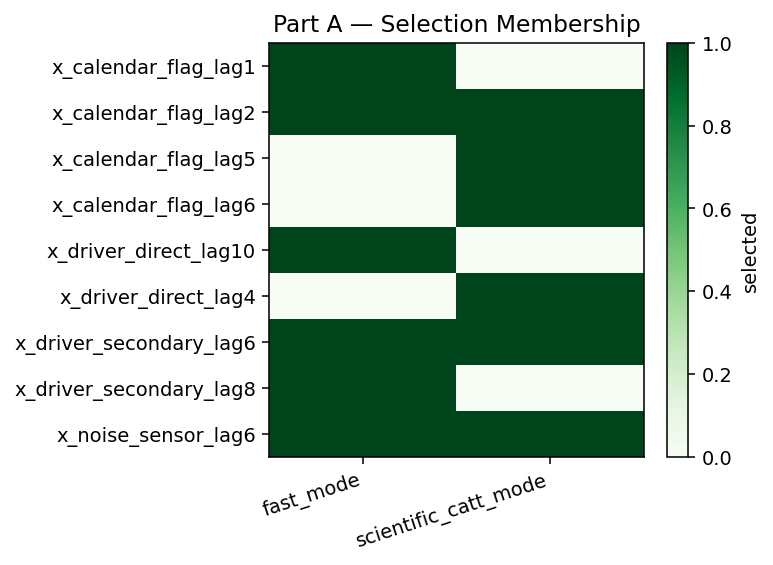

In [3]:
synthetic_panel = build_nonlinear_panel()

SYNTHETIC_HORIZON = 4
SYNTHETIC_CANDIDATE_LAGS = list(range(1, 11))
SYNTHETIC_TARGET_LAGS = [4, 6, 8]
SYNTHETIC_MAX_SELECTED = 6

synthetic_target = synthetic_panel['target'].to_numpy(dtype=float)
synthetic_covariates = {
    column: synthetic_panel[column].to_numpy(dtype=float)
    for column in synthetic_panel.columns
    if column != 'target'
}

synthetic_fast_result, synthetic_catt_result = _run_mode_pair(
    target=synthetic_target,
    covariates=synthetic_covariates,
    forecast_horizon=SYNTHETIC_HORIZON,
    candidate_lags=SYNTHETIC_CANDIDATE_LAGS,
    target_lags=SYNTHETIC_TARGET_LAGS,
    max_selected_features=SYNTHETIC_MAX_SELECTED,
    known_future_covariates={'calendar_flag': 'calendar'},
    run_prefix='walkthrough_10_part_a',
)

synthetic_selected_df = pd.concat(
    [
        _selected_frame(synthetic_fast_result, mode='fast_mode'),
        _selected_frame(synthetic_catt_result, mode='scientific_catt_mode'),
    ],
    ignore_index=True,
)
synthetic_rejected_df = pd.concat(
    [
        _rejected_frame(synthetic_fast_result, mode='fast_mode'),
        _rejected_frame(synthetic_catt_result, mode='scientific_catt_mode'),
    ],
    ignore_index=True,
)
synthetic_blocked_df = pd.concat(
    [
        _blocked_frame(synthetic_fast_result, mode='fast_mode'),
        _blocked_frame(synthetic_catt_result, mode='scientific_catt_mode'),
    ],
    ignore_index=True,
)
synthetic_membership_df = _membership_frame(synthetic_fast_result, synthetic_catt_result)

focus_covariates = ['driver_direct', 'sensor_near_dup', 'sensor_lag_neighbour', 'target_proxy', 'calendar_flag']
synthetic_focus_df = pd.concat([synthetic_selected_df, synthetic_rejected_df], ignore_index=True, sort=False)
synthetic_focus_df = synthetic_focus_df[synthetic_focus_df['covariate_name'].isin(focus_covariates)].reset_index(drop=True)

synthetic_selected_path = TABLE_DIR / 'part_a_selected_rows.csv'
synthetic_blocked_path = TABLE_DIR / 'part_a_blocked_rows.csv'
synthetic_membership_path = TABLE_DIR / 'part_a_mode_comparison.csv'
synthetic_figure_path = FIG_DIR / 'part_a_mode_membership.png'

synthetic_selected_df.to_csv(synthetic_selected_path, index=False)
synthetic_blocked_df.to_csv(synthetic_blocked_path, index=False)
synthetic_membership_df.to_csv(synthetic_membership_path, index=False)
_save_membership_heatmap(
    synthetic_figure_path,
    synthetic_membership_df,
    title='Part A — Selection Membership',
)

print(f'Synthetic panel shape: {synthetic_panel.shape}')
print(f'Measured lags below {SYNTHETIC_HORIZON} are blocked before scoring.')
print(f'Saved synthetic selected rows to: {_relative_output_path(synthetic_selected_path)}')
print(f'Saved synthetic comparison table to: {_relative_output_path(synthetic_membership_path)}')
print(f'Saved synthetic figure to: {_relative_output_path(synthetic_figure_path)}')

display(synthetic_selected_df)
display(synthetic_blocked_df.head(12))
display(synthetic_focus_df)
display(Image(filename=str(synthetic_figure_path)))

Part A is a controlled expected-behavior check, not a proof-of-recovery benchmark. The comparison is useful when you want to see whether the scientific Catt-scored run changes the retained sparse set in the direction you would expect on a nonlinear panel.

## Part B — CausalRivers Applied Walkthrough



This part reuses the established CausalRivers setup from the examples repo. It targets station **978** and compares the lag-aware sparse selections for:



- positives: **979, 1095, 313, 758, 490**

- negatives / controls: **67, 71, 99**



The positive/negative labels come from [walkthroughs/07_causal_rivers_lag_and_feature_selection.ipynb](walkthroughs/07_causal_rivers_lag_and_feature_selection.ipynb), which is the graph-grounded reference surface in this repo. Part B therefore treats CausalRivers as an **applied plausibility walkthrough** and then compares the lag-aware selections against notebook 07 at the driver level and, where the lag window overlaps, at the selected-lag level.


In [4]:
TARGET_ID = 978
POSITIVES = [979, 1095, 313, 758, 490]
NEGATIVES = [67, 71, 99]
ALL_DRIVERS = POSITIVES + NEGATIVES

causal_frame = _load_causal_rivers_frame()
causal_panel = causal_frame[[TARGET_ID, *ALL_DRIVERS]].dropna()
causal_target = causal_panel[TARGET_ID].to_numpy(dtype=float)
causal_covariates = {
    f'station_{station_id}': causal_panel[station_id].to_numpy(dtype=float)
    for station_id in ALL_DRIVERS
}

causal_triage = run_triage(
    TriageRequest(
        series=causal_target,
        goal=AnalysisGoal.univariate,
        max_lag=24,
        n_surrogates=99,
        random_state=SEED,
    )
)

CAUSAL_HORIZON = 4
CAUSAL_CANDIDATE_LAGS = list(range(1, 13))
triage_primary_lags = []
if causal_triage.interpretation is not None:
    triage_primary_lags = list(causal_triage.interpretation.primary_lags)
causal_target_lags = [lag for lag in triage_primary_lags if lag >= CAUSAL_HORIZON]
if len(causal_target_lags) < 2:
    causal_target_lags = [4, 6, 8]
else:
    causal_target_lags = causal_target_lags[:4]

print(f'CausalRivers panel shape: {causal_panel.shape}')
print(f'Triage readiness: {causal_triage.readiness.status}')
print(f'Triage primary lags: {triage_primary_lags}')
print(f'Target-history lags used for lag-aware selection: {causal_target_lags}')

CausalRivers panel shape: (7227, 9)
Triage readiness: clear
Triage primary lags: [1, 2, 3, 4, 5]
Target-history lags used for lag-aware selection: [4, 5]


Saved applied selected rows to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_selected_rows.csv
Saved applied comparison table to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_mode_comparison.csv
Saved applied driver table to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_driver_lag_sets.csv
Saved notebook 07 comparison table to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_vs_walkthrough_07_reference.csv
Saved notebook 07 summary table to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_vs_walkthrough_07_summary.csv
Saved applied figure to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/figures/part_b_driver_lag_counts.png
Notebook 07 reference past covariates: ['station_1095', 'station_313', 'station_490', 'station_758', 'station_979']
Fast mode misses vs notebook 07 contract: []
Scientific mode misses v

,mode,positive_drivers_selected,negative_drivers_selected,positive_lag_count,negative_lag_count
0,notebook_07_reference,5,0,5,0
1,fast_mode,4,3,7,5
2,scientific_catt_mode,4,3,7,5


,driver,role,notebook_07_contract_expectation,notebook_07_selected_lags,notebook_07_legal_lags_in_this_window,fast_selected_lags,scientific_selected_lags,fast_overlap_with_notebook_07,scientific_overlap_with_notebook_07,fast_selected_driver,scientific_selected_driver,fast_matches_notebook_07_contract,scientific_matches_notebook_07_contract
0,station_1095,positive,keep,"[1, 8, 20]",[8],"[4, 5]",[4],[],[],True,True,True,True
1,station_313,positive,keep,"[1, 4, 8]","[4, 8]",[4],[4],[4],[4],True,True,True,True
2,station_490,positive,keep,"[1, 9, 17]",[9],[4],[4],[],[],True,True,True,True
3,station_67,negative/control,drop,"[2, 6, 8]","[6, 8]",[4],[5],[],[],True,True,False,False
4,station_71,negative/control,drop,"[3, 14, 19]",[],"[5, 8]","[4, 6, 8]",[],[],True,True,False,False
5,station_758,positive,keep,"[1, 12, 20]",[12],"[4, 5, 7]","[4, 5, 8, 12]",[],[12],True,True,True,True
6,station_99,negative/control,drop,"[3, 14, 20]",[],"[11, 12]",[11],[],[],True,True,False,False


,driver,station_id,role,fast_selected_lags,scientific_selected_lags
0,station_1095,1095,positive,"[4, 5]",[4]
1,station_313,313,positive,[4],[4]
2,station_490,490,positive,[4],[4]
3,station_67,67,negative/control,[4],[5]
4,station_71,71,negative/control,"[5, 8]","[4, 6, 8]"
5,station_758,758,positive,"[4, 5, 7]","[4, 5, 8, 12]"
6,station_99,99,negative/control,"[11, 12]",[11]


,mode,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score
0,fast_mode,x_station_758_lag4,station_758,4,False,None,1,0.7083,0.0000,0.1806,0.5804
1,fast_mode,x_station_71_lag5,station_71,5,False,None,2,0.8750,0.0966,0.3958,0.4776
2,fast_mode,x_station_99_lag11,station_99,11,False,None,3,0.2917,0.3928,0.1111,0.1574
3,fast_mode,x_station_313_lag4,station_313,4,False,None,4,0.7222,0.6659,0.5208,0.1156
4,fast_mode,x_station_490_lag4,station_490,4,False,None,5,0.6389,0.6976,0.6944,0.0590
...,...,...,...,...,...,...,...,...,...,...,...
19,scientific_catt_mode,x_station_758_lag12,station_758,12,False,None,8,0.6250,0.9237,0.4236,0.0275
20,scientific_catt_mode,x_station_71_lag6,station_71,6,False,None,9,0.8472,0.9587,0.2847,0.0250
21,scientific_catt_mode,x_station_758_lag8,station_758,8,False,None,10,0.5972,0.9247,0.4861,0.0231
22,scientific_catt_mode,x_station_758_lag5,station_758,5,False,None,11,0.5556,0.9278,0.4444,0.0223


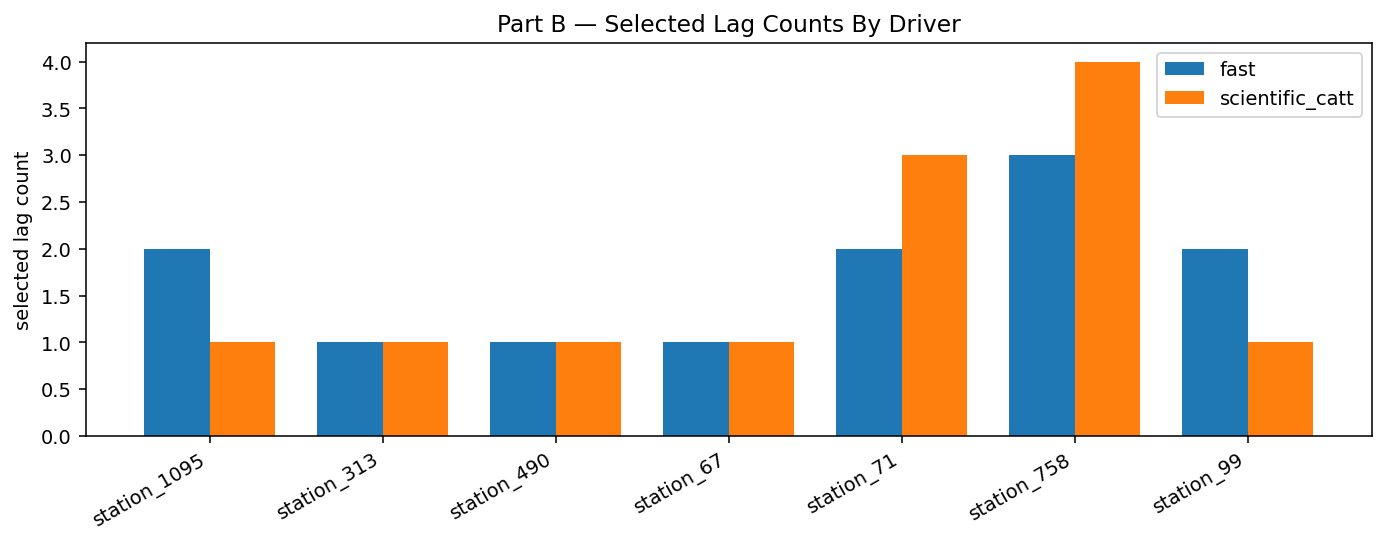

In [5]:
causal_fast_result, causal_catt_result = _run_mode_pair(
    target=causal_target,
    covariates=causal_covariates,
    forecast_horizon=CAUSAL_HORIZON,
    candidate_lags=CAUSAL_CANDIDATE_LAGS,
    target_lags=causal_target_lags,
    max_selected_features=12,
    known_future_covariates=None,
    run_prefix='walkthrough_10_part_b',
)

causal_selected_df = pd.concat(
    [
        _selected_frame(causal_fast_result, mode='fast_mode'),
        _selected_frame(causal_catt_result, mode='scientific_catt_mode'),
    ],
    ignore_index=True,
)
causal_comparison_df = _membership_frame(causal_fast_result, causal_catt_result)
causal_driver_table = _driver_mode_table(
    causal_fast_result,
    causal_catt_result,
    positives=POSITIVES,
    negatives=NEGATIVES,
)

causal_reference_selected_lags = {
    'station_979': [1],
    'station_1095': [1, 8, 20],
    'station_313': [1, 4, 8],
    'station_490': [1, 9, 17],
    'station_67': [2, 6, 8],
    'station_71': [3, 14, 19],
    'station_758': [1, 12, 20],
    'station_99': [3, 14, 20],
}
causal_reference_contract = {
    'past_covariates': ['station_1095', 'station_313', 'station_490', 'station_758', 'station_979'],
    'excluded_negatives': ['station_67', 'station_71', 'station_99'],
}

reference_contract_set = set(causal_reference_contract['past_covariates'])
reference_negative_set = set(causal_reference_contract['excluded_negatives'])
candidate_lag_window = set(CAUSAL_CANDIDATE_LAGS)

reference_rows = []
for row in causal_driver_table.itertuples(index=False):
    reference_full_lags = causal_reference_selected_lags[row.driver]
    reference_legal_lags = [
        lag
        for lag in reference_full_lags
        if lag in candidate_lag_window and lag >= CAUSAL_HORIZON
    ]
    fast_selected_lags = sorted(row.fast_selected_lags)
    scientific_selected_lags = sorted(row.scientific_selected_lags)
    reference_rows.append(
        {
            'driver': row.driver,
            'role': row.role,
            'notebook_07_contract_expectation': 'keep' if row.driver in reference_contract_set else 'drop',
            'notebook_07_selected_lags': reference_full_lags,
            'notebook_07_legal_lags_in_this_window': reference_legal_lags,
            'fast_selected_lags': fast_selected_lags,
            'scientific_selected_lags': scientific_selected_lags,
            'fast_overlap_with_notebook_07': sorted(set(fast_selected_lags).intersection(reference_legal_lags)),
            'scientific_overlap_with_notebook_07': sorted(set(scientific_selected_lags).intersection(reference_legal_lags)),
            'fast_selected_driver': bool(fast_selected_lags),
            'scientific_selected_driver': bool(scientific_selected_lags),
            'fast_matches_notebook_07_contract': (row.driver in reference_contract_set) == bool(fast_selected_lags),
            'scientific_matches_notebook_07_contract': (row.driver in reference_contract_set) == bool(scientific_selected_lags),
        }
    )

causal_reference_df = pd.DataFrame(reference_rows)
causal_reference_summary_df = pd.DataFrame(
    [
        {
            'mode': 'notebook_07_reference',
            'positive_drivers_selected': len(reference_contract_set),
            'negative_drivers_selected': 0,
            'positive_lag_count': sum(
                1
                for driver, lags in causal_reference_selected_lags.items()
                if driver in reference_contract_set
                for lag in lags
                if lag in candidate_lag_window and lag >= CAUSAL_HORIZON
            ),
            'negative_lag_count': 0,
        },
        {
            'mode': 'fast_mode',
            'positive_drivers_selected': sum(
                1 for row in reference_rows if row['role'] == 'positive' and row['fast_selected_driver']
            ),
            'negative_drivers_selected': sum(
                1 for row in reference_rows if row['role'] != 'positive' and row['fast_selected_driver']
            ),
            'positive_lag_count': sum(
                len(row['fast_selected_lags']) for row in reference_rows if row['role'] == 'positive'
            ),
            'negative_lag_count': sum(
                len(row['fast_selected_lags']) for row in reference_rows if row['role'] != 'positive'
            ),
        },
        {
            'mode': 'scientific_catt_mode',
            'positive_drivers_selected': sum(
                1 for row in reference_rows if row['role'] == 'positive' and row['scientific_selected_driver']
            ),
            'negative_drivers_selected': sum(
                1 for row in reference_rows if row['role'] != 'positive' and row['scientific_selected_driver']
            ),
            'positive_lag_count': sum(
                len(row['scientific_selected_lags']) for row in reference_rows if row['role'] == 'positive'
            ),
            'negative_lag_count': sum(
                len(row['scientific_selected_lags']) for row in reference_rows if row['role'] != 'positive'
            ),
        },
    ]
)

causal_selected_path = TABLE_DIR / 'part_b_selected_rows.csv'
causal_comparison_path = TABLE_DIR / 'part_b_mode_comparison.csv'
causal_driver_path = TABLE_DIR / 'part_b_driver_lag_sets.csv'
causal_reference_path = TABLE_DIR / 'part_b_vs_walkthrough_07_reference.csv'
causal_reference_summary_path = TABLE_DIR / 'part_b_vs_walkthrough_07_summary.csv'
causal_figure_path = FIG_DIR / 'part_b_driver_lag_counts.png'

causal_selected_df.to_csv(causal_selected_path, index=False)
causal_comparison_df.to_csv(causal_comparison_path, index=False)
causal_driver_table.to_csv(causal_driver_path, index=False)
causal_reference_df.to_csv(causal_reference_path, index=False)
causal_reference_summary_df.to_csv(causal_reference_summary_path, index=False)
_save_driver_count_plot(
    causal_figure_path,
    causal_driver_table,
    title='Part B — Selected Lag Counts By Driver',
)

fast_reference_misses = sorted(
    row['driver']
    for row in reference_rows
    if row['driver'] in reference_contract_set and not row['fast_selected_driver']
)
scientific_reference_misses = sorted(
    row['driver']
    for row in reference_rows
    if row['driver'] in reference_contract_set and not row['scientific_selected_driver']
)
fast_negative_hits = sorted(
    row['driver']
    for row in reference_rows
    if row['driver'] in reference_negative_set and row['fast_selected_driver']
)
scientific_negative_hits = sorted(
    row['driver']
    for row in reference_rows
    if row['driver'] in reference_negative_set and row['scientific_selected_driver']
)

print(f'Saved applied selected rows to: {_relative_output_path(causal_selected_path)}')
print(f'Saved applied comparison table to: {_relative_output_path(causal_comparison_path)}')
print(f'Saved applied driver table to: {_relative_output_path(causal_driver_path)}')
print(f'Saved notebook 07 comparison table to: {_relative_output_path(causal_reference_path)}')
print(f'Saved notebook 07 summary table to: {_relative_output_path(causal_reference_summary_path)}')
print(f'Saved applied figure to: {_relative_output_path(causal_figure_path)}')
print(f'Notebook 07 reference past covariates: {causal_reference_contract["past_covariates"]}')
print(f'Fast mode misses vs notebook 07 contract: {fast_reference_misses}')
print(f'Scientific mode misses vs notebook 07 contract: {scientific_reference_misses}')
print(f'Fast mode negative-control hits vs notebook 07 contract: {fast_negative_hits}')
print(f'Scientific mode negative-control hits vs notebook 07 contract: {scientific_negative_hits}')

display(causal_reference_summary_df)
display(causal_reference_df)
display(causal_driver_table)
display(causal_selected_df)
display(Image(filename=str(causal_figure_path)))

## Hand-Off To A ForecastPrepContract

The scientific Catt-scored run is used below as the covariate-lag source for a `ForecastPrepContract`. The contract export remains framework-agnostic: it renders a markdown summary and a compact lag table without importing any downstream forecasting library.

In [6]:
causal_contract = build_forecast_prep_contract(
    causal_triage,
    horizon=CAUSAL_HORIZON,
    target_frequency='6h',
    lag_aware_result=causal_catt_result,
    add_calendar_features=False,
)

contract_markdown = forecast_prep_contract_to_markdown(causal_contract)
contract_rows_df = pd.DataFrame(forecast_prep_contract_to_lag_table(causal_contract))

contract_markdown_path = TABLE_DIR / 'part_b_forecast_prep_contract.md'
contract_rows_path = TABLE_DIR / 'part_b_forecast_prep_contract_rows.csv'
contract_markdown_path.write_text(contract_markdown, encoding='utf-8')
contract_rows_df.to_csv(contract_rows_path, index=False)

print(f'Wrote contract markdown: {_relative_output_path(contract_markdown_path)}')
print(f'Wrote contract lag rows: {_relative_output_path(contract_rows_path)}')
print(f'Past covariates: {causal_contract.past_covariates}')
print(f'Future covariates: {causal_contract.future_covariates}')

display(Markdown(contract_markdown))
display(contract_rows_df)

Wrote contract markdown: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_forecast_prep_contract.md
Wrote contract lag rows: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_forecast_prep_contract_rows.csv
Past covariates: ['station_1095', 'station_313', 'station_490', 'station_67', 'station_71', 'station_758', 'station_99']
Future covariates: []


# Forecast Prep Contract

## Metadata

- source_goal: lagged_exogenous
- blocked: False
- readiness_status: clear
- confidence_label: medium
- target_frequency: 6h
- horizon: 4
- contract_version: 0.3.4

## Target Lags

**recommended_target_lags:**
- 1

**recommended_seasonal_lags:**
(none)

**excluded_target_lags:**
(none)

**lag_rationale:**
- lag 1 is the strongest non-seasonal lag
- lag 2 is secondary under current confidence
- lag 3 is secondary under current confidence
- lag 4 is secondary under current confidence
- lag 5 is secondary under current confidence

## Model Families

**recommended_families:**
(none)

**baseline_families:**
- naive
- seasonal_naive

## Covariates

**past_covariates:**
- station_1095
- station_313
- station_490
- station_67
- station_71
- station_758
- station_99

**selected_covariate_lags:**
| axis | kind | driver | selected_lags | feature_names |
| --- | --- | --- | --- | --- |
| past | measured | station_1095 | 4 | x_station_1095_lag4 |
| past | measured | station_313 | 4 | x_station_313_lag4 |
| past | measured | station_490 | 4 | x_station_490_lag4 |
| past | measured | station_67 | 5 | x_station_67_lag5 |
| past | measured | station_71 | 4, 6, 8 | x_station_71_lag4, x_station_71_lag6, x_station_71_lag8 |
| past | measured | station_758 | 4, 5, 8, 12 | x_station_758_lag4, x_station_758_lag5, x_station_758_lag8, x_station_758_lag12 |
| past | measured | station_99 | 11 | x_station_99_lag11 |

**covariate_notes:**
- past covariate station_1095: lags [4]
- past covariate station_313: lags [4]
- past covariate station_490: lags [4]
- past covariate station_67: lags [5]
- past covariate station_71: lags [4, 6, 8]
- past covariate station_758: lags [4, 5, 8, 12]
- past covariate station_99: lags [11]

**future_covariates:**
(none)

**calendar_features:**
(none)

**calendar_locale:** None

**rejected_covariates:**
(none)

**target_history_context:**
- enabled: True
- target_lags: [4, 5]
- scorer_name: catt_knn_mi
- normalization_strategy: rank_percentile
- penalized_selected_features: 12
- max_selected_redundancy: 0.8263888888888888
- notes:
- target-history novelty scored with catt_knn_mi over target lags [4, 5]
- 12 selected feature(s) carried non-zero target-history redundancy

## Notes

**caution_flags:**
(none)

**downstream_notes:**
(none)

**transformation_hints:**
(none)


,driver,axis,role,lag,selected_for_handoff,rationale,feature_name,future_known_required,known_future_provenance,kind
0,target,target,direct,1,True,lag 1 is the strongest non-seasonal lag,NaN,NaN,NaN,NaN
1,station_1095,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_1095_lag4,False,NaN,measured
2,station_313,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_313_lag4,False,NaN,measured
3,station_490,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_490_lag4,False,NaN,measured
4,station_67,past,past,5,True,lag-aware ModMRMR selected sparse measured lags: [5],x_station_67_lag5,False,NaN,measured
5,station_71,past,past,4,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag4,False,NaN,measured
6,station_71,past,past,6,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag6,False,NaN,measured
7,station_71,past,past,8,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag8,False,NaN,measured
8,station_758,past,past,4,True,"lag-aware ModMRMR selected sparse measured lags: [4, 5, 8, 12]",x_station_758_lag4,False,NaN,measured
9,station_758,past,past,5,True,"lag-aware ModMRMR selected sparse measured lags: [4, 5, 8, 12]",x_station_758_lag5,False,NaN,measured


Downstream note: the multi-origin MLForecast pass reuses one fitted model to mirror notebook 07.
Treat it as a hand-off sanity check on false positives and skill, not as a leak-free benchmark.
Saved downstream summary to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_downstream_mlf_summary.csv
Saved downstream driver importance to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_downstream_mlf_driver_importance.csv
Saved downstream walk-forward rows to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_downstream_mlf_walk_forward.csv
Saved downstream single-origin rows to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/tables/part_b_downstream_mlf_single_origin_rows.csv
Saved downstream comparison figure to: outputs/notebooks/walkthroughs/10_lag_aware_catt_scored_mod_mrmr/figures/part_b_downstream_mlf_single_origin_comparison.png
Scientific raw negative-control hits: ['station

,variant,driver_count,lag_feature_count,negative_driver_hits,negative_driver_hit_count,negative_driver_importance,single_origin_mae,single_origin_rmse,single_origin_nse,single_origin_naive_mae,single_origin_skill_pct,walk_forward_origin_count,walk_forward_mae,walk_forward_naive_mae,walk_forward_skill_pct
0,fast_raw,7,12,"station_67, station_71, station_99",3,1041,16.639,18.950,-0.754,24.729,32.716,9,2.457,7.286,66.276
1,scientific_raw,7,12,"station_67, station_71, station_99",3,936,14.845,16.882,-0.392,24.729,39.972,9,2.471,7.286,66.084
2,scientific_drop_known_negatives,4,7,,0,0,13.400,15.470,-0.169,24.729,45.814,9,3.169,7.286,56.505
3,notebook_07_reference_legal_window,4,5,,0,0,12.819,14.601,-0.041,24.729,48.162,9,2.742,7.286,62.372


,variant,driver,role,selected_lags,lag_feature_count,total_importance
5,fast_raw,station_758,positive,"[4, 5, 7]",3,496
4,fast_raw,station_71,negative/control,"[5, 8]",2,426
0,fast_raw,station_1095,positive,"[4, 5]",2,419
1,fast_raw,station_313,positive,[4],1,380
6,fast_raw,station_99,negative/control,"[11, 12]",2,373
...,...,...,...,...,...,...
8,scientific_raw,station_313,positive,[4],1,364
7,scientific_raw,station_1095,positive,[4],1,308
13,scientific_raw,station_99,negative/control,[11],1,292
9,scientific_raw,station_490,positive,[4],1,264


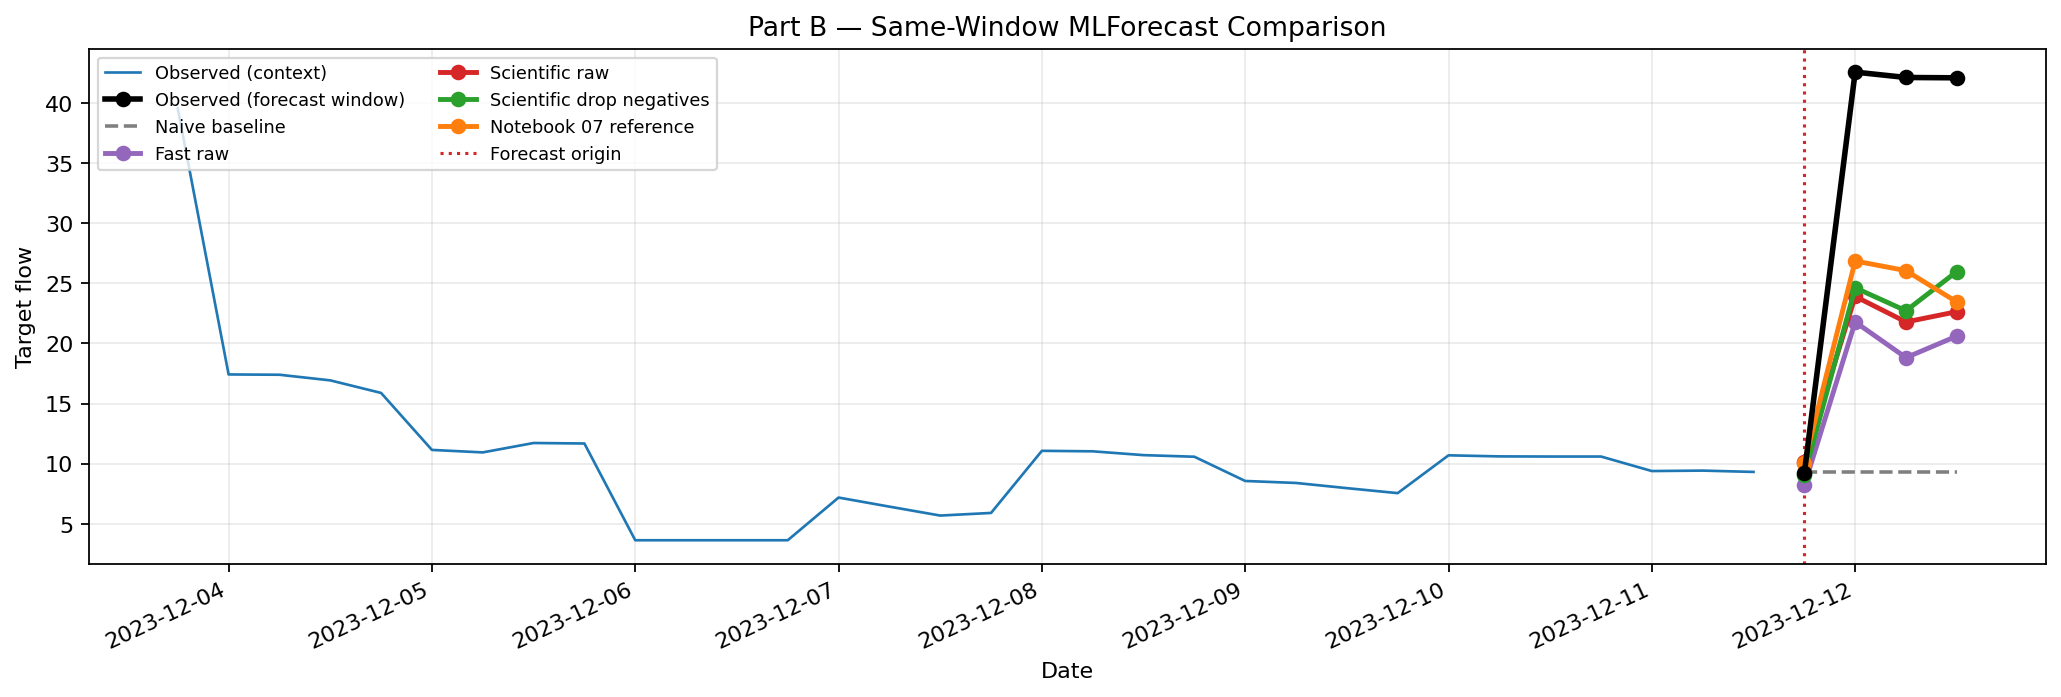

In [7]:
import lightgbm as lgb
from mlforecast import MLForecast


def _variant_display_name(variant_name: str) -> str:
    labels = {
        'fast_raw': 'Fast raw',
        'scientific_raw': 'Scientific raw',
        'scientific_drop_known_negatives': 'Scientific drop negatives',
        'notebook_07_reference_legal_window': 'Notebook 07 reference',
    }
    return labels.get(variant_name, variant_name)


def _downstream_driver_role(driver_name: str) -> str:
    if not driver_name.startswith('station_'):
        return 'other'
    station_id = int(driver_name.split('_', 1)[1])
    if station_id in POSITIVES:
        return 'positive'
    if station_id in NEGATIVES:
        return 'negative/control'
    return 'other'


def _build_downstream_frame(driver_lag_map: dict[str, list[int]]) -> tuple[pd.DataFrame, list[str]]:
    driver_names = sorted(driver_lag_map)
    station_ids = [int(name.split('_', 1)[1]) for name in driver_names]
    base_frame = causal_panel[[TARGET_ID, *station_ids]].copy()
    base_frame.columns = ['y', *driver_names]
    base_frame['unique_id'] = 'unstrut_978'
    base_frame['ds'] = causal_panel.index
    base_columns = ['unique_id', 'ds', 'y', *driver_names]
    base_frame = base_frame.reset_index(drop=True)[base_columns]

    for driver_name, lags in driver_lag_map.items():
        for lag in sorted(set(lags)):
            base_frame[f'{driver_name}_lag{lag}'] = base_frame[driver_name].shift(lag)

    lag_feature_cols = [column for column in base_frame.columns if column not in base_columns]
    model_frame = base_frame.drop(columns=driver_names).dropna().reset_index(drop=True)
    return model_frame, lag_feature_cols


def _save_single_origin_comparison_plot(single_origin_df: pd.DataFrame, *, figure_path: Path) -> None:
    actual_df = (
        single_origin_df[['ds', 'actual', 'naive']]
        .drop_duplicates(subset=['ds'])
        .sort_values('ds')
        .reset_index(drop=True)
    )
    forecast_start = actual_df['ds'].iloc[0]
    context_steps = 8 * CAUSAL_HORIZON
    context_series = causal_panel.loc[causal_panel.index < forecast_start, TARGET_ID].tail(context_steps)

    palette = {
        'fast_raw': 'tab:purple',
        'scientific_raw': 'tab:red',
        'scientific_drop_known_negatives': 'tab:green',
        'notebook_07_reference_legal_window': 'tab:orange',
    }

    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(13, 4.5))
    if not context_series.empty:
        ax.plot(
            context_series.index,
            context_series.to_numpy(),
            label='Observed (context)',
            linewidth=1.2,
            color='tab:blue',
        )
    ax.plot(
        actual_df['ds'],
        actual_df['actual'],
        label='Observed (forecast window)',
        linewidth=2.5,
        marker='o',
        color='black',
        zorder=6,
    )
    ax.plot(
        actual_df['ds'],
        actual_df['naive'],
        label='Naive baseline',
        linewidth=1.6,
        linestyle='--',
        color='tab:gray',
        zorder=4,
    )

    for variant_name, variant_df in single_origin_df.groupby('variant', sort=False):
        variant_df = variant_df.sort_values('ds')
        ax.plot(
            variant_df['ds'],
            variant_df['pred'],
            label=_variant_display_name(variant_name),
            linewidth=2.2,
            marker='o',
            color=palette.get(variant_name),
            zorder=5,
        )

    ax.axvline(forecast_start, color='tab:red', linestyle=':', linewidth=1.4, label='Forecast origin')
    ax.set_title('Part B — Same-Window MLForecast Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Target flow')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    fig.savefig(figure_path, dpi=160, bbox_inches='tight')
    plt.close(fig)


def _evaluate_downstream_variant(
    variant_name: str,
    driver_lag_map: dict[str, list[int]],
) -> dict[str, object]:
    df_full, lag_feature_cols = _build_downstream_frame(driver_lag_map)
    forecast_origin = len(df_full) - CAUSAL_HORIZON
    if forecast_origin <= 0:
        raise ValueError(f'{variant_name}: not enough rows after lagging for downstream evaluation.')

    max_target_lag = max(causal_target_lags)
    history_needed = max_target_lag + CAUSAL_HORIZON + 10
    df_train = df_full.iloc[:forecast_origin].copy()
    history = df_full.iloc[max(0, forecast_origin - history_needed) : forecast_origin].copy()
    window_test = df_full.iloc[forecast_origin : forecast_origin + CAUSAL_HORIZON].copy()
    future_columns = ['unique_id', 'ds', *lag_feature_cols]

    model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.07,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        verbose=-1,
    )
    mlf = MLForecast(models={'lgbm': model}, freq='6h', lags=causal_target_lags)
    mlf.fit(df_train, static_features=[], id_col='unique_id', time_col='ds', target_col='y')

    x_future = None if not lag_feature_cols else window_test[future_columns]
    forecast = mlf.predict(h=CAUSAL_HORIZON, new_df=history, X_df=x_future)

    actual = window_test['y'].to_numpy()
    pred = forecast['lgbm'].to_numpy()
    single_mae = float(np.mean(np.abs(actual - pred)))
    single_rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    ss_total = float(np.sum((actual - actual.mean()) ** 2))
    single_nse = float(1.0 - np.sum((actual - pred) ** 2) / ss_total) if ss_total > 1e-12 else float('nan')
    last_known = float(history['y'].iloc[-1])
    naive_pred = np.full(CAUSAL_HORIZON, last_known)
    single_naive_mae = float(np.mean(np.abs(actual - naive_pred)))
    single_skill_pct = float((1.0 - single_mae / single_naive_mae) * 100.0) if single_naive_mae > 1e-12 else float('nan')
    single_origin_df = pd.DataFrame(
        {
            'variant': variant_name,
            'ds': window_test['ds'].to_numpy(),
            'actual': actual,
            'pred': pred,
            'naive': naive_pred,
        }
    )

    wf_results = []
    wf_start = max(len(df_full) - 10 * CAUSAL_HORIZON, 0)
    wf_origins = list(range(wf_start, len(df_full) - CAUSAL_HORIZON, CAUSAL_HORIZON))
    for origin in wf_origins:
        history_slice = df_full.iloc[max(0, origin - history_needed) : origin].copy()
        window_slice = df_full.iloc[origin : origin + CAUSAL_HORIZON].copy()
        if history_slice.empty or len(window_slice) < CAUSAL_HORIZON:
            continue
        x_slice = None if not lag_feature_cols else window_slice[future_columns]
        forecast_slice = mlf.predict(h=CAUSAL_HORIZON, new_df=history_slice, X_df=x_slice)
        actual_slice = window_slice['y'].to_numpy()
        pred_slice = forecast_slice['lgbm'].to_numpy()
        last_slice = float(history_slice['y'].iloc[-1])
        for horizon_index in range(CAUSAL_HORIZON):
            wf_results.append(
                {
                    'variant': variant_name,
                    'origin_row': origin,
                    'h': horizon_index + 1,
                    'actual': float(actual_slice[horizon_index]),
                    'pred': float(pred_slice[horizon_index]),
                    'naive': last_slice,
                    'err': float(actual_slice[horizon_index] - pred_slice[horizon_index]),
                    'naive_err': float(actual_slice[horizon_index] - last_slice),
                }
            )

    wf_df = pd.DataFrame(wf_results)
    if wf_df.empty:
        wf_mae = float('nan')
        wf_naive_mae = float('nan')
        wf_skill_pct = float('nan')
    else:
        wf_mae = float(wf_df['err'].abs().mean())
        wf_naive_mae = float(wf_df['naive_err'].abs().mean())
        wf_skill_pct = float((1.0 - wf_mae / wf_naive_mae) * 100.0) if wf_naive_mae > 1e-12 else float('nan')

    fitted_model = mlf.models_['lgbm']
    feature_names = list(mlf.ts.features_order_)
    feature_importance = pd.Series(fitted_model.feature_importances_, index=feature_names).sort_values(ascending=False)

    driver_rows = []
    for driver_name in sorted(driver_lag_map):
        importance_columns = [name for name in feature_importance.index if name.startswith(f'{driver_name}_lag')]
        total_importance = int(feature_importance.loc[importance_columns].sum()) if importance_columns else 0
        driver_rows.append(
            {
                'variant': variant_name,
                'driver': driver_name,
                'role': _downstream_driver_role(driver_name),
                'selected_lags': driver_lag_map[driver_name],
                'lag_feature_count': len(driver_lag_map[driver_name]),
                'total_importance': total_importance,
            }
        )
    driver_df = pd.DataFrame(driver_rows)
    negative_hits = sorted(set(driver_lag_map).intersection(reference_negative_set))
    negative_importance = int(driver_df.loc[driver_df['role'] == 'negative/control', 'total_importance'].sum()) if not driver_df.empty else 0

    summary = {
        'variant': variant_name,
        'driver_count': len(driver_lag_map),
        'lag_feature_count': sum(len(lags) for lags in driver_lag_map.values()),
        'negative_driver_hits': ', '.join(negative_hits),
        'negative_driver_hit_count': len(negative_hits),
        'negative_driver_importance': negative_importance,
        'single_origin_mae': single_mae,
        'single_origin_rmse': single_rmse,
        'single_origin_nse': single_nse,
        'single_origin_naive_mae': single_naive_mae,
        'single_origin_skill_pct': single_skill_pct,
        'walk_forward_origin_count': len(wf_origins),
        'walk_forward_mae': wf_mae,
        'walk_forward_naive_mae': wf_naive_mae,
        'walk_forward_skill_pct': wf_skill_pct,
    }
    return {
        'summary': summary,
        'driver_importance': driver_df,
        'walk_forward': wf_df,
        'single_origin': single_origin_df,
    }


fast_raw_map = _driver_lag_map(causal_fast_result)
scientific_raw_map = _driver_lag_map(causal_catt_result)
scientific_drop_negative_map = {
    driver_name: lags
    for driver_name, lags in scientific_raw_map.items()
    if driver_name not in reference_negative_set
}
reference_legal_map = {}
for driver_name in sorted(reference_contract_set):
    legal_lags = [
        lag
        for lag in causal_reference_selected_lags.get(driver_name, [])
        if lag in candidate_lag_window and lag >= CAUSAL_HORIZON
    ]
    if legal_lags:
        reference_legal_map[driver_name] = legal_lags

causal_downstream_variants = {
    'fast_raw': fast_raw_map,
    'scientific_raw': scientific_raw_map,
    'scientific_drop_known_negatives': scientific_drop_negative_map,
    'notebook_07_reference_legal_window': reference_legal_map,
}

variant_outputs = [
    _evaluate_downstream_variant(variant_name, driver_lag_map)
    for variant_name, driver_lag_map in causal_downstream_variants.items()
]

causal_downstream_summary_df = pd.DataFrame(output['summary'] for output in variant_outputs)
causal_downstream_driver_importance_df = pd.concat(
    [output['driver_importance'] for output in variant_outputs],
    ignore_index=True,
)
causal_downstream_walk_forward_df = pd.concat(
    [output['walk_forward'] for output in variant_outputs],
    ignore_index=True,
)
causal_downstream_single_origin_df = pd.concat(
    [output['single_origin'] for output in variant_outputs],
    ignore_index=True,
)

causal_downstream_summary_path = TABLE_DIR / 'part_b_downstream_mlf_summary.csv'
causal_downstream_driver_importance_path = TABLE_DIR / 'part_b_downstream_mlf_driver_importance.csv'
causal_downstream_walk_forward_path = TABLE_DIR / 'part_b_downstream_mlf_walk_forward.csv'
causal_downstream_single_origin_path = TABLE_DIR / 'part_b_downstream_mlf_single_origin_rows.csv'
causal_downstream_plot_path = FIG_DIR / 'part_b_downstream_mlf_single_origin_comparison.png'
causal_downstream_summary_df.to_csv(causal_downstream_summary_path, index=False)
causal_downstream_driver_importance_df.to_csv(causal_downstream_driver_importance_path, index=False)
causal_downstream_walk_forward_df.to_csv(causal_downstream_walk_forward_path, index=False)
causal_downstream_single_origin_df.to_csv(causal_downstream_single_origin_path, index=False)
_save_single_origin_comparison_plot(causal_downstream_single_origin_df, figure_path=causal_downstream_plot_path)

print('Downstream note: the multi-origin MLForecast pass reuses one fitted model to mirror notebook 07.')
print('Treat it as a hand-off sanity check on false positives and skill, not as a leak-free benchmark.')
print(f'Saved downstream summary to: {_relative_output_path(causal_downstream_summary_path)}')
print(f'Saved downstream driver importance to: {_relative_output_path(causal_downstream_driver_importance_path)}')
print(f'Saved downstream walk-forward rows to: {_relative_output_path(causal_downstream_walk_forward_path)}')
print(f'Saved downstream single-origin rows to: {_relative_output_path(causal_downstream_single_origin_path)}')
print(f'Saved downstream comparison figure to: {_relative_output_path(causal_downstream_plot_path)}')
print(f'Scientific raw negative-control hits: {sorted(set(scientific_raw_map).intersection(reference_negative_set))}')
print(f'Scientific drop-known-negatives drivers: {sorted(scientific_drop_negative_map)}')
print(f'Notebook 07 legal-window reference drivers: {sorted(reference_legal_map)}')

display(causal_downstream_summary_df.round(3))
display(
    causal_downstream_driver_importance_df.sort_values(
        ['variant', 'total_importance', 'driver'],
        ascending=[True, False, True],
    )
)
display(Image(filename=str(causal_downstream_plot_path)))

## Closing Notes

- **Part A** is a controlled expected-behavior validation: the question is whether legality, duplicate suppression, and target-history novelty move in the right direction.
- **Part B** is an applied plausibility walkthrough on CausalRivers: it is useful for inspecting sparse selections and hand-off rows, but it is not framed here as a hard recovery benchmark.
- The `ForecastPrepContract` section shows where the deterministic triage workflow stops and where downstream forecasting code would begin in a separate recipe or framework integration.